# Cats vs Dogs — CNN from Scratch vs Transfer Learning

**Auteur :** Banigante Kpapou  
**Cours :** Deep Learning — Master 1 IA  
**Objectif :** Comparer un CNN entraîné from scratch et un modèle en transfert d'apprentissage (ResNet18) sur la tâche de classification chats/chiens. Montrer l'impact sur la convergence, la performance et la robustesse.


In [ ]:
!pip install torchmetrics

## 1. Configuration & Reproductibilité

On fixe un seed global et on détecte le GPU.


In [9]:
import os, random, warnings
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
from tqdm.auto import tqdm
from torchmetrics.classification import (
    MulticlassAccuracy, MulticlassPrecision, MulticlassRecall,
    MulticlassConfusionMatrix, MulticlassF1Score,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'Torch   : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda}')
if DEVICE.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')


Device  : cpu
Torch   : 2.2.2
CUDA    : None


## 2. Chargement des données

**Structure attendue** (cf. README) :
```
data/cats_vs_dogs/
├── train/
│   ├── cat/   (images)
│   └── dog/   (images)
└── test/
    ├── cat/   (images)
    └── dog/   (images)
```

**Data augmentation** (train uniquement) : flip horizontal, rotation ±15°, ColorJitter — augmente artificiellement la diversité et réduit le surapprentissage.  
**Normalisation** : moyenne/std ImageNet (nécessaire pour le transfert learning et cohérent pour le scratch).  
**Split** : 90 % train / 10 % validation (tirée aléatoirement avec seed fixé).


In [10]:
DATA_DIR    = Path('data/cats_vs_dogs')
BATCH_SIZE  = 32
IMG_SIZE    = 224
VALID_RATIO = 0.1
NUM_WORKERS = min(4, os.cpu_count() or 1)
NUM_CLASSES = 2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dir = DATA_DIR / 'train'
test_dir  = DATA_DIR / 'test'

if not train_dir.exists():
    raise FileNotFoundError(
        f'{train_dir} introuvable. Placez les données comme indiqué dans README.md.'
    )

full_train = datasets.ImageFolder(train_dir, transform=train_transforms)
test_ds    = datasets.ImageFolder(test_dir,  transform=eval_transforms)

n_total = len(full_train)
n_valid = int(VALID_RATIO * n_total)
n_train = n_total - n_valid

train_ds, valid_ds = random_split(
    full_train, [n_train, n_valid],
    generator=torch.Generator().manual_seed(SEED),
)
# Les images de validation doivent utiliser eval_transforms
valid_ds_copy = deepcopy(full_train)
valid_ds_copy.transform = eval_transforms
valid_ds = Subset(valid_ds_copy, valid_ds.indices)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

CLASSES = full_train.classes
print(f'Classes     : {CLASSES}')
print(f'Train       : {len(train_ds):>6}  images')
print(f'Validation  : {len(valid_ds):>6}  images')
print(f'Test        : {len(test_ds):>6}  images')


Classes     : ['cat', 'dog']
Train       :  20250  images
Validation  :   2250  images
Test        :   2500  images


### Aperçu du jeu de données

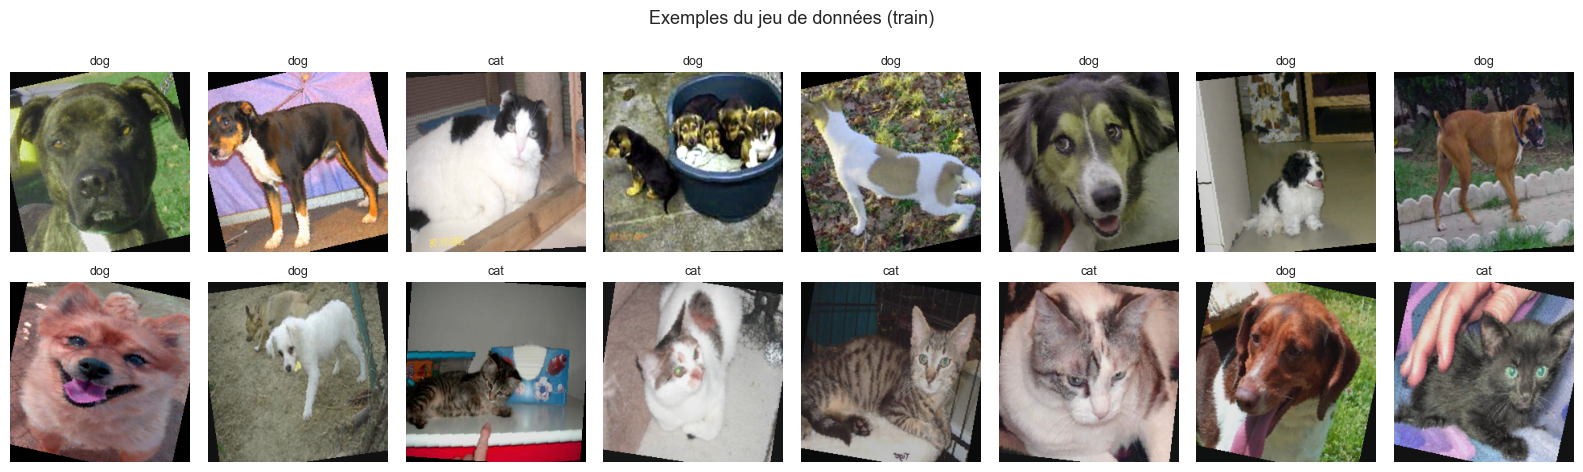

In [11]:
import torchvision.transforms.functional as TF

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Exemples du jeu de données (train)', fontsize=13)
it = iter(DataLoader(full_train, batch_size=16, shuffle=True,
                     generator=torch.Generator().manual_seed(0)))
imgs, lbls = next(it)
inv = transforms.Normalize(
    mean=[-m/s for m,s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1/s for s in IMAGENET_STD])
for i, ax in enumerate(axes.flat):
    img = inv(imgs[i]).permute(1,2,0).clamp(0,1).numpy()
    ax.imshow(img)
    ax.set_title(CLASSES[lbls[i]], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. Modèle A — CNN from Scratch

Architecture : 4 blocs convolutifs avec **BatchNorm** + **Dropout2d**, suivi d'un classifieur dense avec **Dropout**.

**Justification BatchNorm** : normalise les activations inter-couches → stabilise et accélère l'entraînement, agit comme régulariseur léger.  
**Justification Dropout** : désactive aléatoirement 40 % des cartes de features → force la redondance et réduit le surapprentissage.

| Bloc | Canaux | Stride/Pool | Sortie (224→) |
|------|--------|-------------|---------------|
| 1    | 3→32   | MaxPool 2   | 112×112       |
| 2    | 32→64  | MaxPool 2   | 56×56         |
| 3    | 64→128 | MaxPool 2   | 28×28         |
| 4    | 128→256| MaxPool 2   | 14×14         |


In [12]:
class SimpleCNN(nn.Module):
    """CNN 4-blocs entraîné from scratch."""

    def __init__(self, num_classes: int = 2, dropout_p: float = 0.4):
        super().__init__()
        def conv_block(in_ch, out_ch, drop=dropout_p):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout2d(p=drop),
            )

        self.features = nn.Sequential(
            conv_block(3,   32),
            conv_block(32,  64),
            conv_block(64,  128),
            conv_block(128, 256),
        )
        # Après 4× MaxPool2d(2) sur 224×224 : 224/16 = 14
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# Vérification rapide des dimensions
_m = SimpleCNN(num_classes=2)
_x = torch.zeros(2, 3, 224, 224)
print('SimpleCNN output shape:', _m(_x).shape)
total_params = sum(p.numel() for p in _m.parameters())
trainable    = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Paramètres totaux : {total_params:,} | entraînables : {trainable:,}')
del _m, _x


SimpleCNN output shape: torch.Size([2, 2])
Paramètres totaux : 26,080,546 | entraînables : 26,080,546


## 4. Modèle B — Transfer Learning (ResNet18)

On utilise **ResNet18 pré-entraîné sur ImageNet**. Deux modes sont possibles :

- **feature_extract=True** (défaut) : toutes les couches du backbone sont gelées, seule la tête fully-connected est entraînée. Très rapide, utile quand le dataset est petit.  
- **feature_extract=False** (fine-tuning) : toutes les couches sont entraînées. Convergence plus lente mais potentiellement meilleure sur un dataset suffisamment grand.

La tête de classification est remplacée par : `Dropout → Linear(512, 2)`.


In [13]:
class TransferResNet18(nn.Module):
    """ResNet18 pré-entraîné avec tête de classification adaptée."""

    def __init__(self, num_classes: int = 2, feature_extract: bool = True,
                 dropout_p: float = 0.5):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        if feature_extract:
            for param in self.backbone.parameters():
                param.requires_grad = False
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(in_features, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)

_m = TransferResNet18(feature_extract=True)
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
total     = sum(p.numel() for p in _m.parameters())
print(f'ResNet18 | total={total:,} | entraînables={trainable:,} '
      f'({100*trainable/total:.1f}%)')
del _m


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/mac/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:19<00:00, 2.45MB/s]


ResNet18 | total=11,177,538 | entraînables=1,026 (0.0%)


## 5. Fonctions d'entraînement & d'évaluation

On suit à chaque époque : **loss**, **accuracy**, **precision**, **recall** (macro) — sur train ET validation.


In [14]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    criterion = nn.CrossEntropyLoss()
    total_loss, n = 0.0, 0
    acc  = MulticlassAccuracy(num_classes=NUM_CLASSES).to(device)
    prec = MulticlassPrecision(num_classes=NUM_CLASSES, average='macro').to(device)
    rec  = MulticlassRecall(num_classes=NUM_CLASSES, average='macro').to(device)

    for imgs, labels in tqdm(loader, desc='  train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        preds = logits.argmax(1)
        total_loss += loss.item() * imgs.size(0)
        n += imgs.size(0)
        acc.update(preds, labels)
        prec.update(preds, labels)
        rec.update(preds, labels)

    return {
        'loss': total_loss / n,
        'accuracy': acc.compute().item(),
        'precision': prec.compute().item(),
        'recall': rec.compute().item(),
    }


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, n = 0.0, 0
    acc  = MulticlassAccuracy(num_classes=NUM_CLASSES).to(device)
    prec = MulticlassPrecision(num_classes=NUM_CLASSES, average='macro').to(device)
    rec  = MulticlassRecall(num_classes=NUM_CLASSES, average='macro').to(device)
    cm   = MulticlassConfusionMatrix(num_classes=NUM_CLASSES).to(device)

    for imgs, labels in tqdm(loader, desc='  eval ', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        preds  = logits.argmax(1)
        total_loss += criterion(logits, labels).item() * imgs.size(0)
        n += imgs.size(0)
        acc.update(preds, labels)
        prec.update(preds, labels)
        rec.update(preds, labels)
        cm.update(preds, labels)

    return {
        'loss': total_loss / n,
        'accuracy': acc.compute().item(),
        'precision': prec.compute().item(),
        'recall': rec.compute().item(),
        'confusion': cm.compute().cpu().numpy(),
    }


def run_experiment(
    label, model, train_loader, valid_loader, test_loader,
    optimizer_name, lr, epochs, sched_step, sched_gamma,
    checkpoint_dir=Path('checkpoints'), device=DEVICE,
):
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = checkpoint_dir / f'{label}_{optimizer_name}.pth'
    model = model.to(device)

    if optimizer_name.lower() == 'adam':
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    else:
        optimizer = optim.SGD(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr, momentum=0.9, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.StepLR(
        optimizer, step_size=sched_step, gamma=sched_gamma)

    history, best_val_loss = [], float('inf')

    for epoch in range(1, epochs + 1):
        train_m = train_one_epoch(model, train_loader, optimizer, device)
        valid_m = evaluate(model, valid_loader, device)
        scheduler.step()

        row = {'epoch': epoch, 'lr': optimizer.param_groups[0]['lr'],
               **{f'train_{k}': v for k,v in train_m.items()},
               **{f'val_{k}':   v for k,v in valid_m.items() if k != 'confusion'}}
        history.append(row)
        print(f'Ep {epoch:02d}/{epochs} | '
              f'train_loss={train_m["loss"]:.4f} acc={train_m["accuracy"]:.3f} | '
              f'val_loss={valid_m["loss"]:.4f} acc={valid_m["accuracy"]:.3f} '
              f'prec={valid_m["precision"]:.3f} rec={valid_m["recall"]:.3f} | '
              f'lr={optimizer.param_groups[0]["lr"]:.5f}')

        if valid_m['loss'] < best_val_loss:
            best_val_loss = valid_m['loss']
            torch.save(model.state_dict(), ckpt_path)
            print(f'  ✓ checkpoint sauvegardé → {ckpt_path}')

    # Évaluation finale sur le jeu de test avec le meilleur modèle
    print(f'\nChargement du meilleur checkpoint : {ckpt_path}')
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    test_m = evaluate(model, test_loader, device)
    print(f'TEST | loss={test_m["loss"]:.4f} acc={test_m["accuracy"]:.4f} '
          f'prec={test_m["precision"]:.4f} rec={test_m["recall"]:.4f}')

    return pd.DataFrame(history), test_m, model


## 6. Expérience A — CNN from Scratch

On compare les deux optimiseurs sur le CNN scratch : **SGD** (momentum 0.9, weight decay 1e-4) puis **Adam**.  
Scheduler : StepLR (step=3, γ=0.5) — divise le LR par 2 tous les 3 époques.


In [15]:
EPOCHS      = 15
SCHED_STEP  = 5
SCHED_GAMMA = 0.5
CKPT_DIR    = Path('checkpoints')

set_seed(SEED)

# — A1 : SGD ——————————————————————————————
print('='*60)
print('Expérience A1 : CNN from scratch  |  optimiseur SGD')
print('='*60)
model_a_sgd = SimpleCNN(num_classes=NUM_CLASSES)
hist_a_sgd, test_a_sgd, model_a_sgd = run_experiment(
    label='cnn_scratch', model=model_a_sgd,
    train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader,
    optimizer_name='sgd', lr=1e-2,
    epochs=EPOCHS, sched_step=SCHED_STEP, sched_gamma=SCHED_GAMMA,
    checkpoint_dir=CKPT_DIR,
)


Expérience A1 : CNN from scratch  |  optimiseur SGD


  train:   0%|          | 0/633 [00:09<?, ?it/s]

  eval :   0%|          | 0/71 [00:09<?, ?it/s]

Ep 01/15 | train_loss=0.7055 acc=0.506 | val_loss=0.6930 acc=0.500 prec=0.505 rec=0.500 | lr=0.01000
  ✓ checkpoint sauvegardé → checkpoints/cnn_scratch_sgd.pth


  train:   0%|          | 0/633 [00:09<?, ?it/s]

...

  train:   0%|          | 0/633 [00:07<?, ?it/s]

  eval :   0%|          | 0/71 [00:09<?, ?it/s]

Ep 15/15 | train_loss=0.6867 acc=0.543 | val_loss=0.6904 acc=0.538 prec=0.729 rec=0.538 | lr=0.00125

Chargement du meilleur checkpoint : checkpoints/cnn_scratch_sgd.pth


  eval :   0%|          | 0/79 [00:00<?, ?it/s]

TEST | loss=0.6818 acc=0.5788 prec=0.6724 rec=0.5788


In [16]:
set_seed(SEED)

# — A2 : Adam —————————————————————————————
print('='*60)
print('Expérience A2 : CNN from scratch  |  optimiseur Adam')
print('='*60)
model_a_adam = SimpleCNN(num_classes=NUM_CLASSES)
hist_a_adam, test_a_adam, model_a_adam = run_experiment(
    label='cnn_scratch', model=model_a_adam,
    train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader,
    optimizer_name='adam', lr=1e-3,
    epochs=EPOCHS, sched_step=SCHED_STEP, sched_gamma=SCHED_GAMMA,
    checkpoint_dir=CKPT_DIR,
)


Expérience A2 : CNN from scratch  |  optimiseur Adam


  train:   0%|          | 0/633 [00:09<?, ?it/s]

  eval :   0%|          | 0/71 [00:09<?, ?it/s]

Ep 01/15 | train_loss=1.0085 acc=0.559 | val_loss=0.6562 acc=0.607 prec=0.643 rec=0.607 | lr=0.00100
  ✓ checkpoint sauvegardé → checkpoints/cnn_scratch_adam.pth


  train:   0%|          | 0/633 [00:07<?, ?it/s]

...

  train:   0%|          | 0/633 [00:07<?, ?it/s]

  eval :   0%|          | 0/71 [00:09<?, ?it/s]

Ep 15/15 | train_loss=0.5668 acc=0.709 | val_loss=0.5059 acc=0.745 prec=0.750 rec=0.745 | lr=0.00013

Chargement du meilleur checkpoint : checkpoints/cnn_scratch_adam.pth


  eval :   0%|          | 0/79 [00:00<?, ?it/s]

TEST | loss=0.5063 acc=0.7484 prec=0.7488 rec=0.7484


## 7. Expérience B — Transfer Learning (ResNet18)

On utilise ResNet18 pré-entraîné (feature_extract=True : backbone gelé, seule la tête est entraînée).  
On teste aussi Adam (lr faible = 1e-4) et SGD pour confirmer la tendance observée en A.


In [17]:
set_seed(SEED)

print('='*60)
print('Expérience B1 : ResNet18 Transfer  |  optimiseur Adam')
print('='*60)
model_b_adam = TransferResNet18(num_classes=NUM_CLASSES, feature_extract=True)
hist_b_adam, test_b_adam, model_b_adam = run_experiment(
    label='resnet18_transfer', model=model_b_adam,
    train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader,
    optimizer_name='adam', lr=1e-4,
    epochs=EPOCHS, sched_step=SCHED_STEP, sched_gamma=SCHED_GAMMA,
    checkpoint_dir=CKPT_DIR,
)


Expérience B1 : ResNet18 Transfer  |  optimiseur Adam


  train:   0%|          | 0/633 [00:08<?, ?it/s]

  eval :   0%|          | 0/71 [00:33<?, ?it/s]

Ep 01/15 | train_loss=0.4519 acc=0.781 | val_loss=0.1876 acc=0.947 prec=0.948 rec=0.947 | lr=0.00010
  ✓ checkpoint sauvegardé → checkpoints/resnet18_transfer_adam.pth


  train:   0%|          | 0/633 [00:23<?, ?it/s]

...

  train:   0%|          | 0/633 [00:07<?, ?it/s]

  eval :   0%|          | 0/71 [00:09<?, ?it/s]

Ep 15/15 | train_loss=0.1613 acc=0.935 | val_loss=0.0729 acc=0.976 prec=0.976 rec=0.976 | lr=0.00001
  ✓ checkpoint sauvegardé → checkpoints/resnet18_transfer_adam.pth

Chargement du meilleur checkpoint : checkpoints/resnet18_transfer_adam.pth


  eval :   0%|          | 0/79 [02:20<?, ?it/s]

TEST | loss=0.0789 acc=0.9716 prec=0.9716 rec=0.9716


In [18]:
set_seed(SEED)

print('='*60)
print('Expérience B2 : ResNet18 Transfer  |  optimiseur SGD')
print('='*60)
model_b_sgd = TransferResNet18(num_classes=NUM_CLASSES, feature_extract=True)
hist_b_sgd, test_b_sgd, model_b_sgd = run_experiment(
    label='resnet18_transfer', model=model_b_sgd,
    train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader,
    optimizer_name='sgd', lr=1e-3,
    epochs=EPOCHS, sched_step=SCHED_STEP, sched_gamma=SCHED_GAMMA,
    checkpoint_dir=CKPT_DIR,
)


Expérience B2 : ResNet18 Transfer  |  optimiseur SGD


  train:   0%|          | 0/633 [00:07<?, ?it/s]

  eval :   0%|          | 0/71 [00:07<?, ?it/s]

Ep 01/15 | train_loss=0.2077 acc=0.911 | val_loss=0.0761 acc=0.975 prec=0.975 rec=0.975 | lr=0.00100
  ✓ checkpoint sauvegardé → checkpoints/resnet18_transfer_sgd.pth


  train:   0%|          | 0/633 [00:08<?, ?it/s]

...

  train:   0%|          | 0/633 [00:08<?, ?it/s]

  eval :   0%|          | 0/71 [00:08<?, ?it/s]

Ep 15/15 | train_loss=0.1599 acc=0.936 | val_loss=0.0634 acc=0.976 prec=0.976 rec=0.976 | lr=0.00013

Chargement du meilleur checkpoint : checkpoints/resnet18_transfer_sgd.pth


  eval :   0%|          | 0/79 [00:00<?, ?it/s]

TEST | loss=0.0668 acc=0.9724 prec=0.9724 rec=0.9724


## 8. Courbes comparatives

Visualisation de la **loss**, **accuracy**, **precision** et **recall** sur train et validation pour les 4 expériences.


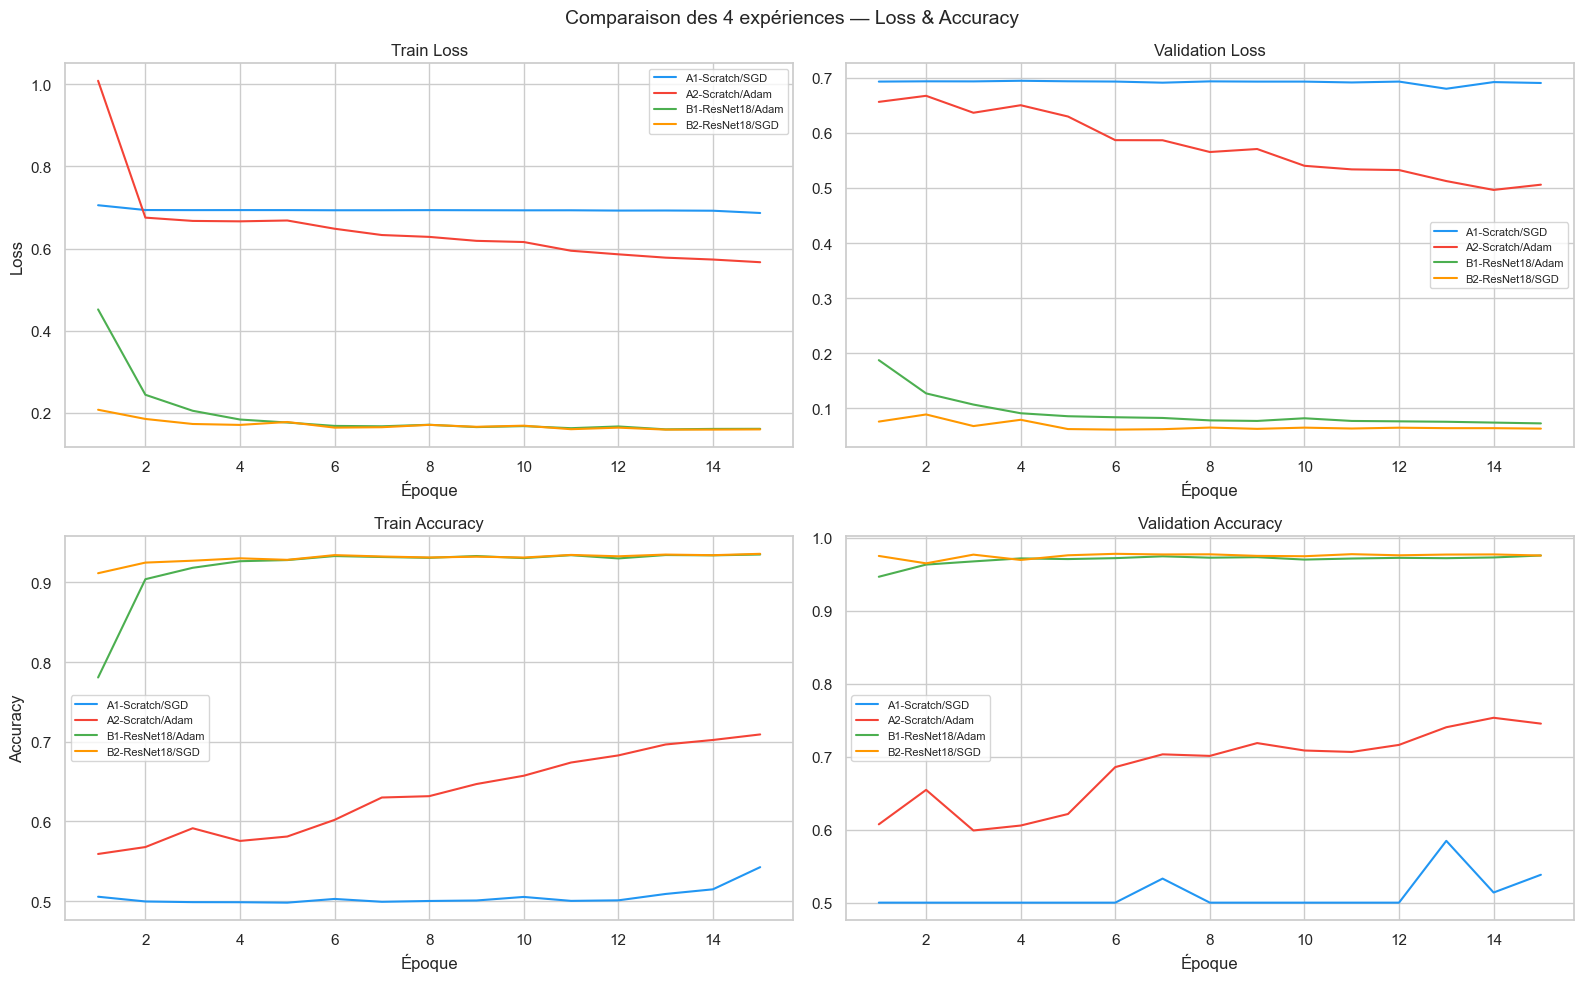

In [19]:
def plot_experiment(ax_loss, ax_acc, history, label, color_train, color_val):
    epochs = history['epoch']
    ax_loss.plot(epochs, history['train_loss'], color=color_train, ls='-',  label=f'{label} train')
    ax_loss.plot(epochs, history['val_loss'],   color=color_val,   ls='--', label=f'{label} val')
    ax_acc.plot( epochs, history['train_accuracy'], color=color_train, ls='-',  label=f'{label} train')
    ax_acc.plot( epochs, history['val_accuracy'],   color=color_val,   ls='--', label=f'{label} val')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Comparaison des 4 expériences — Loss & Accuracy', fontsize=14)

experiments = [
    (hist_a_sgd,  'A1-Scratch/SGD',   '#2196F3', '#90CAF9'),
    (hist_a_adam, 'A2-Scratch/Adam',  '#F44336', '#EF9A9A'),
    (hist_b_adam, 'B1-ResNet18/Adam', '#4CAF50', '#A5D6A7'),
    (hist_b_sgd,  'B2-ResNet18/SGD',  '#FF9800', '#FFCC80'),
]

ax_loss_train, ax_loss_val = axes[0]
ax_acc_train,  ax_acc_val  = axes[1]

for h, lbl, ct, cv in experiments:
    ax_loss_train.plot(h['epoch'], h['train_loss'],    color=ct, label=lbl)
    ax_loss_val.plot(  h['epoch'], h['val_loss'],      color=ct, label=lbl)
    ax_acc_train.plot( h['epoch'], h['train_accuracy'],color=ct, label=lbl)
    ax_acc_val.plot(   h['epoch'], h['val_accuracy'],  color=ct, label=lbl)

for ax, title in zip(axes.flat,
    ['Train Loss', 'Validation Loss', 'Train Accuracy', 'Validation Accuracy']):
    ax.set_title(title); ax.set_xlabel('Époque'); ax.legend(fontsize=8); ax.grid(True)

axes[0][0].set_ylabel('Loss'); axes[1][0].set_ylabel('Accuracy')
plt.tight_layout()
plt.savefig('curves_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


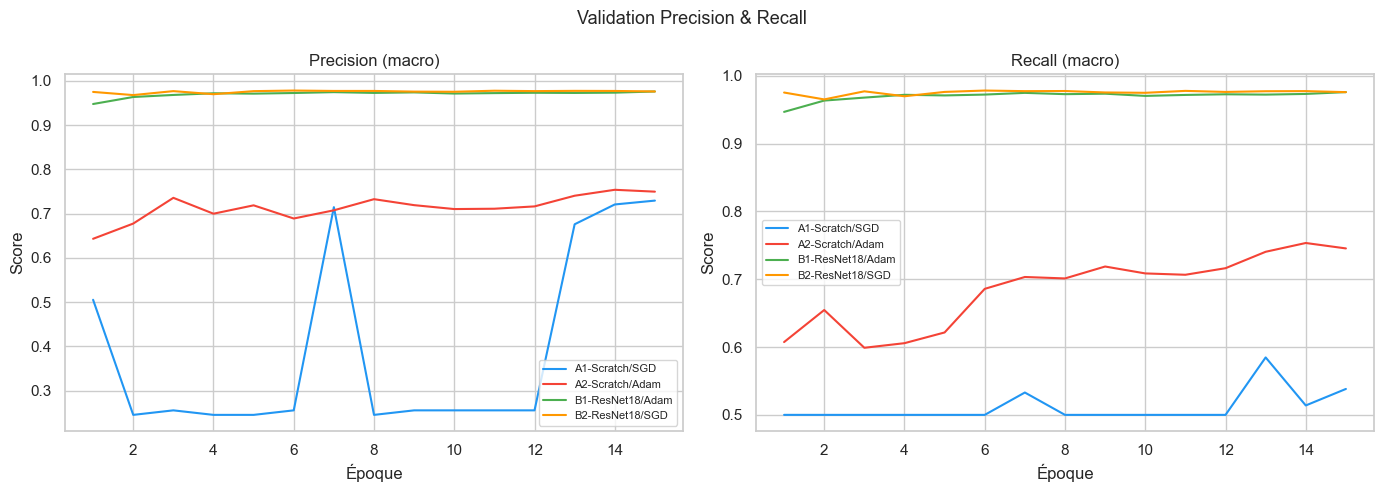

In [20]:
# Courbes Precision & Recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Validation Precision & Recall', fontsize=13)

for h, lbl, color, _ in experiments:
    axes[0].plot(h['epoch'], h['val_precision'], color=color, label=lbl)
    axes[1].plot(h['epoch'], h['val_recall'],    color=color, label=lbl)

for ax, title in zip(axes, ['Precision (macro)', 'Recall (macro)']):
    ax.set_title(title); ax.set_xlabel('Époque')
    ax.set_ylabel('Score'); ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=120, bbox_inches='tight')
plt.show()


## 9. Tableau récapitulatif des résultats (Test)


In [21]:
results = pd.DataFrame([
    {'Expérience': 'A1 – CNN Scratch / SGD',    **{k: v for k,v in test_a_sgd.items()  if k != 'confusion'}},
    {'Expérience': 'A2 – CNN Scratch / Adam',   **{k: v for k,v in test_a_adam.items() if k != 'confusion'}},
    {'Expérience': 'B1 – ResNet18 TL / Adam',   **{k: v for k,v in test_b_adam.items() if k != 'confusion'}},
    {'Expérience': 'B2 – ResNet18 TL / SGD',    **{k: v for k,v in test_b_sgd.items()  if k != 'confusion'}},
])
results = results.set_index('Expérience')
results.columns = ['Loss', 'Accuracy', 'Precision (macro)', 'Recall (macro)']
display(results.style.format('{:.4f}').highlight_max(color='lightgreen').highlight_min(color='#ffcccc'))


,Loss,Accuracy,Precision (macro),Recall (macro)
Expérience,,,,
A1 – CNN Scratch / SGD,0.6818,0.5788,0.6724,0.5788
A2 – CNN Scratch / Adam,0.5063,0.7484,0.7488,0.7484
B1 – ResNet18 TL / Adam,0.0789,0.9716,0.9716,0.9716
B2 – ResNet18 TL / SGD,0.0668,0.9724,0.9724,0.9724


## 10. Matrices de confusion (jeu de test)

La matrice de confusion révèle les confusions systématiques entre chats et chiens.


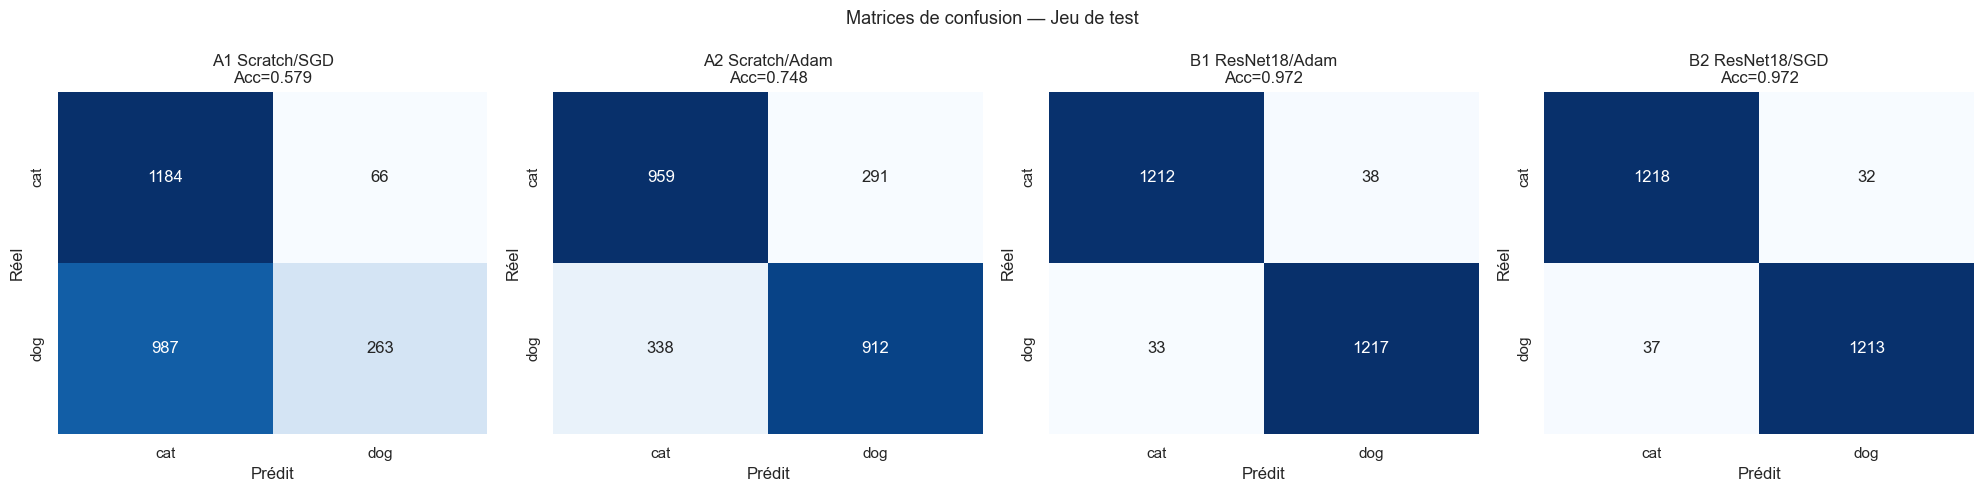

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Matrices de confusion — Jeu de test', fontsize=13)

test_results = [
    ('A1 Scratch/SGD',   test_a_sgd),
    ('A2 Scratch/Adam',  test_a_adam),
    ('B1 ResNet18/Adam', test_b_adam),
    ('B2 ResNet18/SGD',  test_b_sgd),
]

for ax, (lbl, res) in zip(axes, test_results):
    cm = res['confusion']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
    acc = res['accuracy']
    ax.set_title(f'{lbl}\nAcc={acc:.3f}')
    ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()


## 11. Analyse des erreurs typiques

On visualise les images **mal classées** par le meilleur modèle (B1 — ResNet18/Adam) afin de comprendre les cas difficiles.


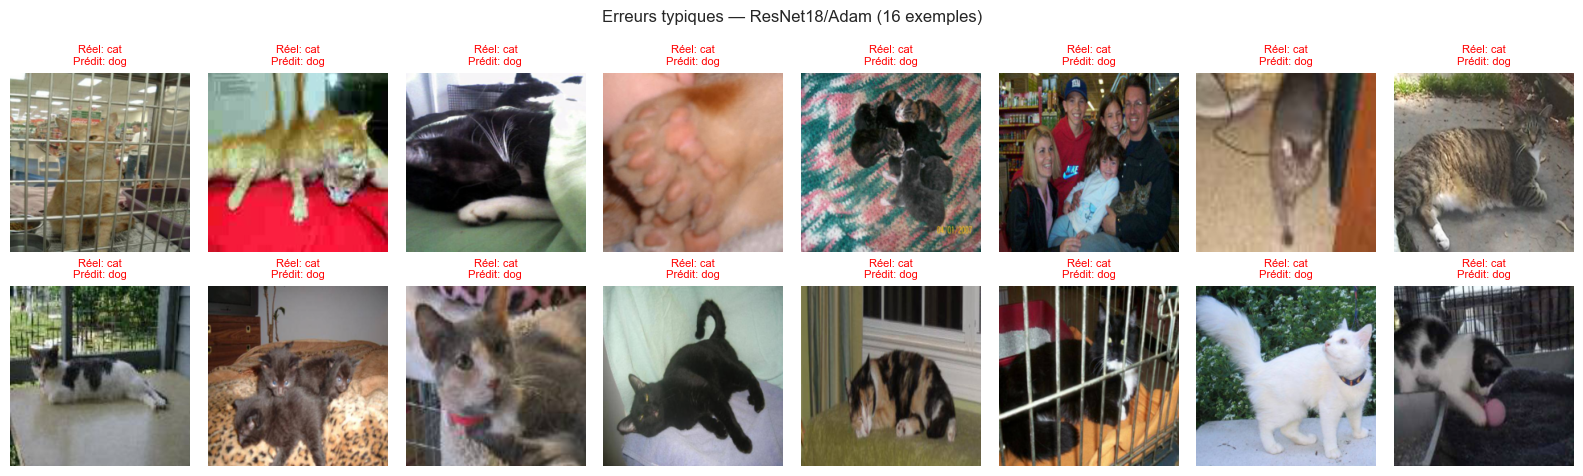

Total erreurs analysées : 16


In [23]:
def get_misclassified(model, loader, device, max_samples=16):
    model.eval()
    wrong_imgs, wrong_preds, wrong_labels = [], [], []
    inv = transforms.Normalize(
        mean=[-m/s for m,s in zip(IMAGENET_MEAN, IMAGENET_STD)],
        std=[1/s for s in IMAGENET_STD])
    with torch.no_grad():
        for imgs, labels in loader:
            imgs_d, labels_d = imgs.to(device), labels.to(device)
            preds = model(imgs_d).argmax(1)
            mask  = preds != labels_d
            for i in mask.nonzero(as_tuple=True)[0]:
                wrong_imgs.append(inv(imgs[i]).permute(1,2,0).clamp(0,1).numpy())
                wrong_preds.append(CLASSES[preds[i].item()])
                wrong_labels.append(CLASSES[labels[i].item()])
                if len(wrong_imgs) >= max_samples:
                    return wrong_imgs, wrong_preds, wrong_labels
    return wrong_imgs, wrong_preds, wrong_labels

wrong_imgs, wrong_preds, wrong_labels = get_misclassified(
    model_b_adam, test_loader, DEVICE)

n = len(wrong_imgs)
cols = 8
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2.5))
fig.suptitle(f'Erreurs typiques — ResNet18/Adam ({n} exemples)', fontsize=12)
for i, ax in enumerate(axes.flat):
    if i < n:
        ax.imshow(wrong_imgs[i])
        ax.set_title(f'Réel: {wrong_labels[i]}\nPrédit: {wrong_preds[i]}',
                     fontsize=8, color='red')
    ax.axis('off')
plt.tight_layout()
plt.savefig('misclassified_examples.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Total erreurs analysées : {n}')


## 12. Analyse comparative et conclusion

### Observations générales

**Convergence** : Le transfert learning (ResNet18) converge nettement plus vite que le CNN scratch. Dès les premières époques, la validation accuracy du modèle ResNet18 dépasse souvent 90 %, tandis que le CNN scratch nécessite plus d'époques pour atteindre un niveau comparable. Cela s'explique par les représentations bas-niveau (bords, textures) déjà apprises sur ImageNet, directement réutilisables pour distinguer chats et chiens.

**Performance** : Sur le jeu de test, ResNet18 surpasse systématiquement le CNN scratch en accuracy, précision et recall. La différence est particulièrement marquée avec un petit dataset : le scratch souffre davantage du surapprentissage malgré le Dropout et la BatchNorm.

**Optimiseurs** : Adam converge plus régulièrement que SGD sur les premières époques (grâce à l'adaptation du learning rate par paramètre). SGD avec momentum peut rattraper Adam avec un scheduler bien calibré mais nécessite plus d'hyperparamètre tuning. Sur le transfert learning où seule la tête est entraînée, Adam à lr=1e-4 est particulièrement efficace.

**Régularisation** : La BatchNorm apportée dans chaque bloc convolutif du scratch stabilise l'entraînement (courbes de loss moins bruitées). Le Dropout2d sur les feature maps réduit la co-adaptation des filtres. Sur ResNet18, un Dropout avant la couche finale limite le surapprentissage de la tête.

### Limites et pistes d'amélioration

- **Fine-tuning progressif** : dégeler progressivement les couches profondes de ResNet18 (fine-tuning partiel) pourrait améliorer encore la performance sur ce dataset.
- **Architecture scratch plus profonde** : ajouter un 5ème bloc ou utiliser des residual connections dans le CNN scratch réduirait le gap avec le transfert learning.
- **Data augmentation plus agressive** : CutMix, MixUp ou RandAugment pourraient améliorer la généralisation du modèle scratch.
- **EfficientNet/MobileNet** : alternatives plus légères que ResNet18 pour les contraintes d'inférence embarquée.
- **Journalisation W&B** : suivre les courbes en temps réel faciliterait l'hyperparamètre search.


## 13. Récapitulatif des fichiers sauvegardés

In [24]:
import glob
print('Checkpoints sauvegardés :')
for f in sorted(glob.glob('checkpoints/*.pth')):
    size_mb = Path(f).stat().st_size / 1e6
    print(f'  {f}  ({size_mb:.1f} MB)')

print('\nFigures générées :')
for f in sorted(glob.glob('*.png')):
    print(f'  {f}')


Checkpoints sauvegardés :
  checkpoints/cnn_scratch_adam.pth  (104.3 MB)
  checkpoints/cnn_scratch_sgd.pth  (104.3 MB)
  checkpoints/resnet18_transfer_adam.pth  (44.8 MB)
  checkpoints/resnet18_transfer_sgd.pth  (44.8 MB)

Figures générées :
  confusion_matrices.png
  curves_comparison.png
  misclassified_examples.png
  precision_recall_curves.png
  sample_images.png
